LIBRARIES

In [1]:
#import dataiku

import pandas as pd, numpy as np

#from dataiku import pandasutils as pdu



In [2]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

import statsmodels

import statsmodels.api as sm

import statsmodels.formula.api as smf



In [4]:
# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

import os

import sys

from scipy import stats

import matplotlib.pyplot as plt

import seaborn as sns

# %matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.linear_model import LinearRegression  # Add this import

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE



In [5]:
from datetime import date

import holidays

from workalendar.europe import France

import datetime


DATA PREPARATION

In [ ]:
data = pd.read_csv(r"C:\Users\utilisateur\Downloads\wetransfer_histo_gazpar_merged-3-csv-gz_2026-01-30_1023\histo_gazpar_merged(1).csv.gz")


In [9]:
data.shape

(2797952, 35)

In [10]:
data['pce']=data['pce'].astype(str)


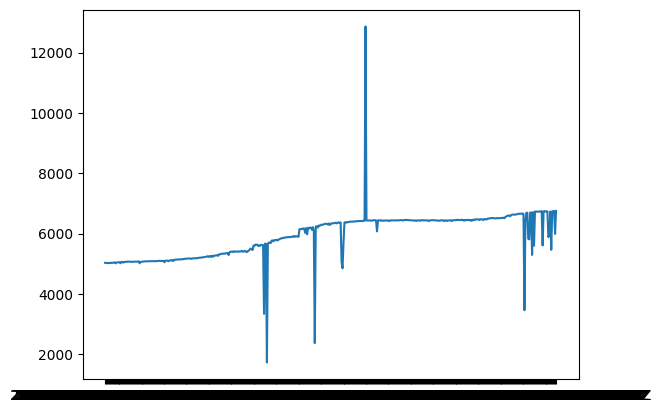

In [136]:
nb_pce = data.groupby('date_parsed')['pce'].count()
plt.plot(nb_pce.index, nb_pce.values)

In [137]:

def add_leading_zeros(pce_value):

    if len(pce_value) <= 13:

        # Pad the string with leading zeros to make it 14 characters long

        return pce_value.zfill(14)

    else:

        return pce_value

# Apply the function to the 'pce' column

data['pce'] = data['pce'].apply(add_leading_zeros)


In [138]:
data = data.sort_values(by=['pce', 'gasday'])

data['trend'] = data.groupby('pce').cumcount() + 1

In [ ]:
print(data.columns)

In [ ]:
data['gasday'] = pd.to_datetime(data['gasday']).dt.date

# Function to determine if a day is a workday (Mon-Fri) or weekend (Sat-Sun)

def is_workday(date):

   return 1 if date.weekday() < 5 else 0

# Apply the function to create the Workday column

data['workday'] = data['gasday'].apply(is_workday)

data['weekend'] = 1-data['workday']

In [144]:
# ## Add Holidays

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: CODE

# Assuming col 'year'

unique_years = data['year'].unique()

# Convert unique_years to integers and create a list

unique_years_list = unique_years.astype(int).tolist()

# Create an empty dictionary to store the holidays for each year

fr_holidays = {}

# Iterate through unique years and get the public holidays for each year

for year in unique_years_list:

    fr_holidays[year] = holidays.France(years=[year])

# Flatten the holiday dictionary for easier lookup

all_holidays = {date: name for year in fr_holidays for date, name in fr_holidays[year].items()}

all_holidays


# Create a new column indicating whether each date is a public holiday (1 or 0)

data['Is_Public_Holiday'] = data['gasday'].apply(lambda x: 1 if x in all_holidays else 0)

# Create a column with the holiday name or an empty string if it is not a holiday

data['Holiday_Name'] = data['gasday'].apply(lambda x: all_holidays.get(x, ''))


In [145]:
# Determine if it's a non-working day

data['non_working_day'] = data['weekend'] | data['Is_Public_Holiday']


In [146]:
# Count observations per category

data['count'] = data.groupby('pce')['pce'].transform('count')

In [154]:
# Check for missing values and drop rows with missing values

data_nona = data.dropna(subset=['valeur_energie_conso', 'hdd', 'trend', 'pce'])


In [20]:
# Subset the dataset where column 'is_outlier' is not equal to -1

# data_nona = data_nona[data_nona['is_outlier'] != -1]

# data_nona.shape

data_nona = data_nona[(data_nona['hdd'] != 0) & (data['valeur_energie_conso'] != 0)]

In [42]:
# Residuals
model_lmm = smf.mixedlm("valeur_energie_conso ~ hdd", 
                        data=data_nona, 
                        groups=data_nona['pce'], 
                        re_formula="~hdd")

result_lmm = model_lmm.fit(method=["lbfgs"]) 


fixed_intercept = result_lmm.params['Intercept']
fixed_slope = result_lmm.params['hdd']

re_df = pd.DataFrame.from_dict(result_lmm.random_effects, orient='index')

re_df = re_df.rename(columns={'hdd': 'rand_slope'})
col_intercept = [c for c in re_df.columns if c != 'rand_slope'][0] 
re_df = re_df.rename(columns={col_intercept: 'rand_intercept'})

re_df.index.name = 'pce'

data_nona = data_nona.merge(re_df, on='pce', how='left')

data_nona['intercept_client'] = fixed_intercept + data_nona['rand_intercept']
data_nona['pente_client'] = fixed_slope + data_nona['rand_slope']

# Prédiction by pce and residuals
data_nona['conso_predite'] = data_nona['intercept_client'] + (data_nona['pente_client'] * data_nona['hdd'])
data_nona['conso_residu'] = data_nona['valeur_energie_conso'] - data_nona['conso_predite']

# IQR Cleaning
def remove_outliers_iqr(group):
    # Analysis on the residuals
    Q1 = group['conso_residu'].quantile(0.25)
    Q3 = group['conso_residu'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return group[(group['conso_residu'] >= lower_bound) & (group['conso_residu'] <= upper_bound)]

# Filtering
data_nona = data_nona.groupby('pce').apply(remove_outliers_iqr).reset_index(drop=True)

# Drop columns
cols_to_drop = ['temp_scaled', 'rand_intercept', 'rand_slope', 'intercept_client', 
                'pente_client', 'conso_predite', 'conso_residu']
data_nona = data_nona.drop(columns=[c for c in cols_to_drop if c in data_nona.columns])

# Dropping pce < 1 year
if 'year' in data_nona.columns:
    pce_counts = data_nona.groupby('pce')['year'].nunique()
    consistent_pce = pce_counts[pce_counts >= 2].index
    data_nona = data_nona[data_nona['pce'].isin(consistent_pce)]
else:
    data_nona = data_nona.copy()

c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 201387.963948
  warnings.warn(msg, ConvergenceWarning)
c:\Users\utilisateur\Desktop\programmation\Statap\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, Conver

In [ ]:
# FE weights are related to overall residual variance (Captures "leftover" variability within groups after accounting for both fixed and random effects), RE varince (Captures how much group-specific deviations (random effects) vary around the population average (fixed effects).the RE variance-covariance matrix is used to weight the FE estimates and their uncertainty. The FE estimates are derived by "pooling" group-specific effects, with pooling weights determined by:

# The relative magnitude of within-group vs. between-group variance,

# Correlations between random effects (e.g., intercept-slope covariance).

# -------------------------------------------------------------------------------- NOTEBOOK-CELL: MARKDOWN

# ## Models

In [45]:
#%%time

lmm_default = smf.mixedlm(

    formula='valeur_energie_conso ~ hdd + trend + Is_Public_Holiday',

    data=data_nona,

    groups="pce",

    re_formula="~hdd + 1"

).fit(method=["lbfgs"], maxiter=600)

lmm_default.summary()



<class 'statsmodels.iolib.summary2.Summary'>
"""
              Mixed Linear Model Regression Results
==================================================================
Model:            MixedLM Dependent Variable: valeur_energie_conso
No. Observations: 1419343 Method:             REML                
No. Groups:       7427    Scale:              209.6326            
Min. group size:  3       Log-Likelihood:     -5845654.6874       
Max. group size:  428     Converged:          Yes                 
Mean group size:  191.1                                           
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               6.786    0.154  43.994 0.000  6.483  7.088
hdd                     5.874    0.045 130.001 0.000  5.786  5.963
trend                   0.002    0.000  15.956 0.000  0.001  0.002
Is_Public_Holiday      -2.497    0.071 -35.353 0.000 -2.636 -2.359
pce Var               166.952    0.206                            
pce x hdd Cov          11.713    0.042                            
hdd Var                15.071    0.017                            
==================================================================

"""

In [46]:
df_random_effects_default = pd.DataFrame.from_dict(lmm_default.random_effects, orient='index')


In [47]:
# Add fixed effects to the DataFrame

df_random_effects_default['Fixed intercept'] = lmm_default.fe_params.loc['Intercept']

df_random_effects_default['Fixed slope trend'] = lmm_default.fe_params.loc['trend']

df_random_effects_default['Fixed slope Is_Public_Holiday'] = lmm_default.fe_params.loc['Is_Public_Holiday']

df_random_effects_default['Fixed slope hdd'] = lmm_default.fe_params.loc['hdd']

In [48]:
# Rename columns for clarity

df_random_effects_default = df_random_effects_default.rename({

    'pce': 'Random intercept',

    'hdd': 'Random slope hdd'

}, axis=1)


In [ ]:
# Calculate the combined (fixed + random) effects

df_random_effects_default['INTERCEPT LMM'] = df_random_effects_default['Random intercept'] + df_random_effects_default['Fixed intercept']

df_random_effects_default['SLOPE LMM hdd'] = df_random_effects_default['Random slope hdd'] + df_random_effects_default['Fixed slope hdd']

In [50]:
# delete id needed

df_random_effects = df_random_effects_default


In [51]:
df_random_effects = df_random_effects.reset_index().rename(columns={'index': 'pce'})


In [29]:
df_random_effects

,pce,Random intercept,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd
0,22114761187602,7.051824,-0.434997,8.565324,0.005579,-3.646053,5.823298,15.617148,5.388301
1,22114761188829,27.092570,-1.717639,8.565324,0.005579,-3.646053,5.823298,35.657895,4.105659
2,22114761191548,-9.709267,0.617184,8.565324,0.005579,-3.646053,5.823298,-1.143943,6.440481
3,22114761192886,-1.161910,0.075395,8.565324,0.005579,-3.646053,5.823298,7.403415,5.898692
4,22114761202808,4.526642,-0.287282,8.565324,0.005579,-3.646053,5.823298,13.091966,5.536016
...,...,...,...,...,...,...,...,...,...
7952,22157452873546,-3.840480,0.247940,8.565324,0.005579,-3.646053,5.823298,4.724845,6.071238
7953,22157452876350,-7.247012,0.458581,8.565324,0.005579,-3.646053,5.823298,1.318313,6.281878
7954,22157452887265,9.284888,-0.562030,8.565324,0.005579,-3.646053,5.823298,17.850213,5.261267
7955,22157452890759,-3.651189,0.237431,8.565324,0.005579,-3.646053,5.823298,4.914136,6.060729


In [52]:
merged_df = df_random_effects


In [53]:
data_nona_unique = data_nona[['pce', 'count']].drop_duplicates(subset='pce')


In [54]:
# Convert 'pce' column in both DataFrames to string

merged_df['pce'] = merged_df['pce'].astype(str)

data_nona_unique['pce'] = data_nona_unique['pce'].astype(str)

merged_df=pd.merge(merged_df, data_nona_unique[['pce', 'count']], on='pce', how='left')


In [55]:
merged_df


,pce,Random intercept,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd,count
0,22114761187602,0.846170,3.604619,6.785664,0.001592,-2.497294,5.874167,7.631833,9.478786,466
1,22114761188829,42.736706,7.986923,6.785664,0.001592,-2.497294,5.874167,49.522369,13.861090,290
2,22114761191548,-9.183502,-2.020182,6.785664,0.001592,-2.497294,5.874167,-2.397839,3.853985,445
3,22114761192886,-1.876972,0.285497,6.785664,0.001592,-2.497294,5.874167,4.908692,6.159664,358
4,22114761202808,9.758131,0.449151,6.785664,0.001592,-2.497294,5.874167,16.543794,6.323318,470
...,...,...,...,...,...,...,...,...,...,...
7422,22157452873546,-14.007026,0.979785,6.785664,0.001592,-2.497294,5.874167,-7.221362,6.853952,266
7423,22157452876350,-6.747869,-1.172015,6.785664,0.001592,-2.497294,5.874167,0.037795,4.702152,470
7424,22157452887265,-9.624720,7.339599,6.785664,0.001592,-2.497294,5.874167,-2.839056,13.213766,451
7425,22157452890759,-14.459331,1.028546,6.785664,0.001592,-2.497294,5.874167,-7.673668,6.902713,225


In [76]:
df_results = data_nona.copy()
df_results = df_results.merge(merged_df, on='pce', how='left')


In [69]:

# Calcul de la Consommation Normalisée (On retire l'effet météo spécifique à ce client pour ne garder que le comportement : Conso_Norm = Conso_Reelle - (Sensibilité_Client * Météo)
df_results['conso_norm'] = df_results['valeur_energie_conso'] - (df_results['SLOPE LMM hdd'] * df_results['hdd'])


[]

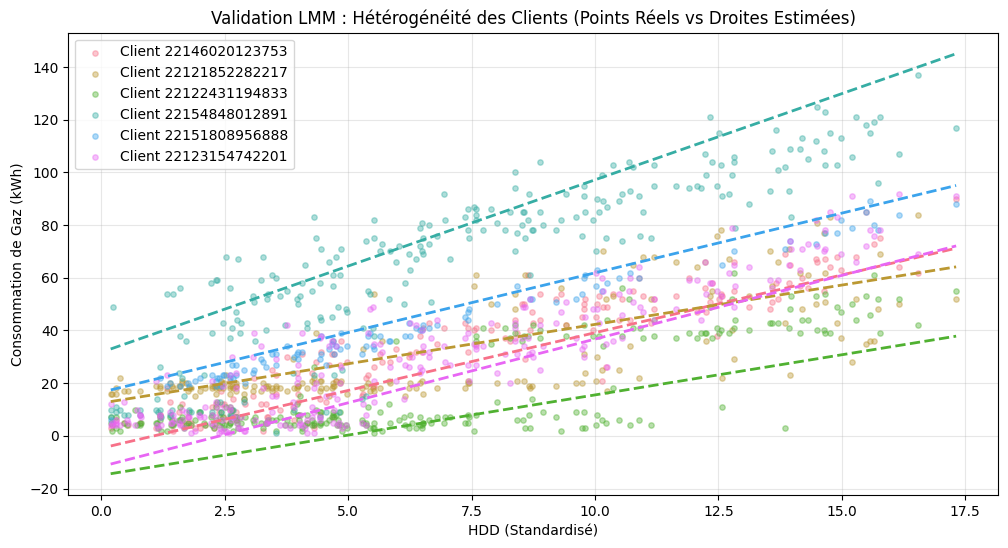

In [74]:
# Objectif : Montrer que chaque client réagit différemment au froid (Pentes aléatoires)

# Sélection de 6 clients aléatoires
sample_pces = np.random.choice(df_results['pce'].unique(), 6, replace=False)
subset_plot = df_results[df_results['pce'].isin(sample_pces)].copy()

plt.figure(figsize=(12, 6))

# Palette de couleurs pour distinguer les clients
colors = sns.color_palette("husl", len(sample_pces))

for i, pce in enumerate(sample_pces):
    pce_data = subset_plot[subset_plot['pce'] == pce]
    color = colors[i]
    
    # Nuage de points
    plt.scatter(pce_data['hdd'], pce_data['valeur_energie_conso'], 
                alpha=0.4, s=15, color=color, label=f"Client {pce}")
    
    # Droite du Modèle LMM (Pente spécifique à ce client)
    # y = (Intercept_Fixe + Intercept_Random) + (Pente_Fixe + Pente_Random) * X
    intercept_fixed = pce_data['INTERCEPT LMM'].iloc[0]
    intercept_total = intercept_fixed + pce_data['Random intercept'].iloc[0]
    slope_total = pce_data['SLOPE LMM hdd'].iloc[0]
    
    # Création de la ligne de régression
    x_vals = np.array([pce_data['hdd'].min(), pce_data['hdd'].max()])
    y_vals = intercept_total + slope_total * x_vals
    
    plt.plot(x_vals, y_vals, color=color, linewidth=2, linestyle='--')

plt.title("Validation LMM : Hétérogénéité des Clients (Points Réels vs Droites Estimées)")
plt.xlabel("HDD (Standardisé)")
plt.ylabel("Consommation de Gaz (kWh)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.plot()

In [132]:
plt.figure(figsize=(14, 6))

# On agrège par jour pour alléger le graphique
daily_trend = df_results.groupby('date_parsed')['conso_norm'].mean()

# Tracé de la courbe
plt.plot(daily_trend.index, daily_trend.values, color='#e67e22', linewidth=1.5, label='Conso Normalisée (Météo corrigée)')

# Ajout d'une moyenne mobile pour voir la tendance de fond (Trend)
plt.plot(daily_trend.rolling(window=30).mean().index, 
         daily_trend.rolling(window=30).mean().values, 
         color='blue', linewidth=2, linestyle='-', label='Tendance (Moyenne Mobile 30j)')

plt.title("Évolution de la Consommation Normalisée (2024-2025)")
plt.ylabel("Consommation Moyenne Corrigée (kWh)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'Column not found: conso_norm'

<Figure size 1400x600 with 0 Axes>

In [100]:
df_final = df_results.copy()

,code_station_meteo_pitd,pce,pce_releve,pitd,freq_rel,segmnt,profil,car,business_u_finale,freq_rel_1,...,Random slope hdd,Fixed intercept,Fixed slope trend,Fixed slope Is_Public_Holiday,Fixed slope hdd,INTERCEPT LMM,SLOPE LMM hdd,count_y,slope_pce,conso_corr
0,75114001,22114761187602,22114761187602,GD1058,1M,RES,P012,19423,DGP,1M,...,3.604619,6.785664,0.001592,-2.497294,5.874167,7.631833,9.478786,466,9.289017,3.210077
1,75114001,22114761187602,22114761187602,GD1058,1M,RES,P012,19423,DGP,1M,...,3.604619,6.785664,0.001592,-2.497294,5.874167,7.631833,9.478786,466,9.289017,1.210029
2,75114001,22114761187602,22114761187602,GD1058,1M,RES,P012,19423,DGP,1M,...,3.604619,6.785664,0.001592,-2.497294,5.874167,7.631833,9.478786,466,9.289017,-16.606917
3,75114001,22114761187602,22114761187602,GD1058,1M,RES,P012,19423,DGP,1M,...,3.604619,6.785664,0.001592,-2.497294,5.874167,7.631833,9.478786,466,9.289017,-19.627634
4,75114001,22114761187602,22114761187602,GD1058,1M,RES,P012,19423,DGP,1M,...,3.604619,6.785664,0.001592,-2.497294,5.874167,7.631833,9.478786,466,9.289017,-21.193166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1419338,75114001,22157452891436,22157452891436,GD1057,1M,RES,P012,31494,DGP,1M,...,12.818895,6.785664,0.001592,-2.497294,5.874167,-5.727533,18.693062,452,16.907768,181.096228
1419339,75114001,22157452891436,22157452891436,GD1057,1M,RES,P012,31494,DGP,1M,...,12.818895,6.785664,0.001592,-2.497294,5.874167,-5.727533,18.693062,452,16.907768,162.597037
1419340,75114001,22157452891436,22157452891436,GD1057,1M,RES,P012,31494,DGP,1M,...,12.818895,6.785664,0.001592,-2.497294,5.874167,-5.727533,18.693062,452,16.907768,182.147852
1419341,75114001,22157452891436,22157452891436,GD1057,1M,RES,P012,31494,DGP,1M,...,12.818895,6.785664,0.001592,-2.497294,5.874167,-5.727533,18.693062,452,16.907768,172.239504


In [ ]:
nb_pce = df_results.groupby('date_parsed')['pce'].count()

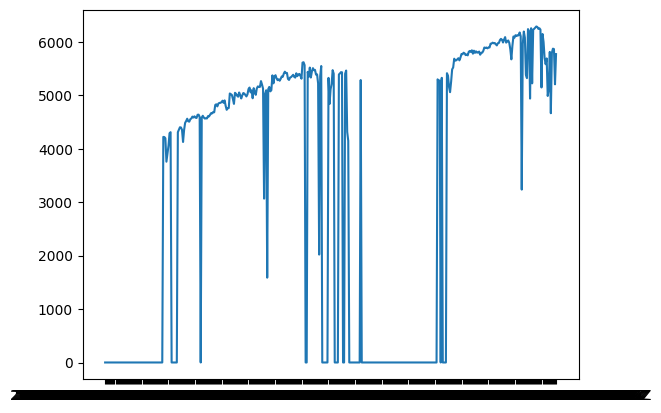

In [134]:
plt.plot(nb_pce.index, nb_pce.values)

[]

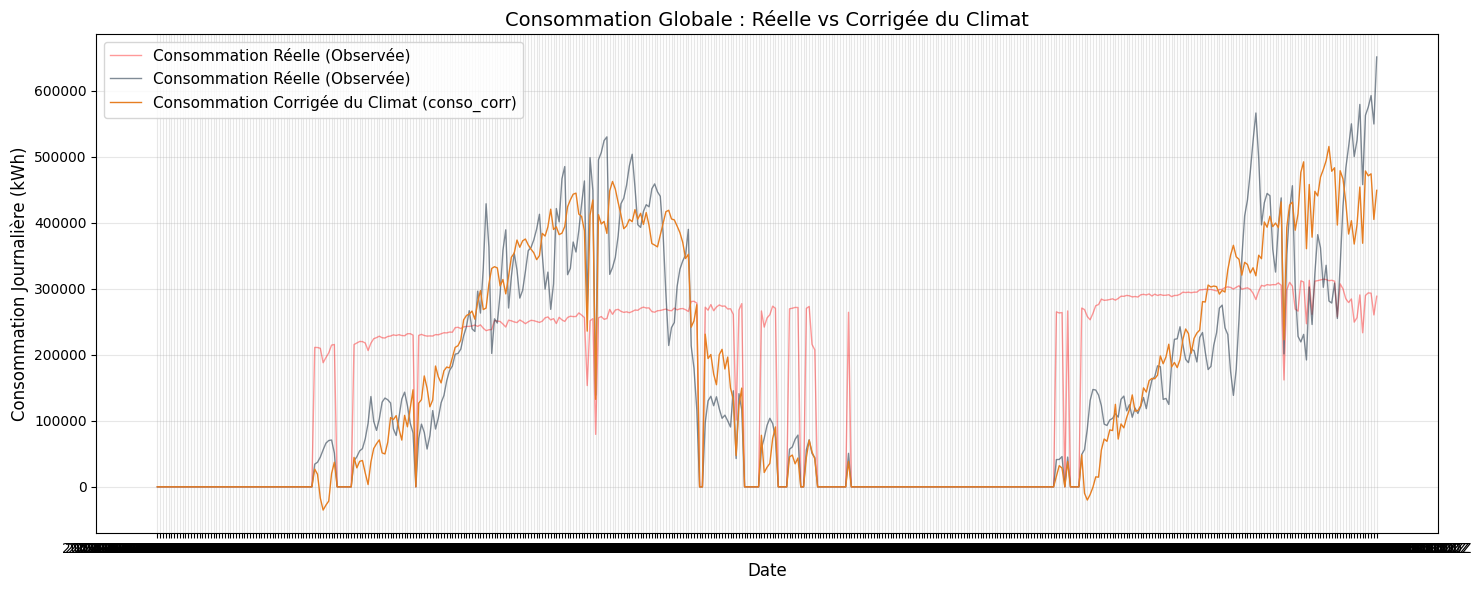

In [135]:
daily_real = df_results.groupby('date_parsed')['valeur_energie_conso'].sum()
daily_corr = df_results.groupby('date_parsed')['conso_corr'].sum()
nb_pce = df_results.groupby('date_parsed')['pce'].count()

# Création du graphique
plt.figure(figsize=(15, 6))

plt.plot()

# Courbe de la consommation brute observée
plt.plot(nb_pce.index, nb_pce.values*50, 
         label='Consommation Réelle (Observée)', 
         color="#ff0000", alpha=0.4, linewidth=1)

# Courbe de la consommation brute observée
plt.plot(real_smooth.index, daily_real.values, 
         label='Consommation Réelle (Observée)', 
         color='#2c3e50', alpha=0.6, linewidth=1)

# Courbe de la consommation corrigée (lissée de l'effet météo)
plt.plot(corr_smooth.index, daily_corr.values, 
         label='Consommation Corrigée du Climat (conso_corr)', 
         color='#e67e22', linewidth=1)

plt.title("Consommation Globale : Réelle vs Corrigée du Climat", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Consommation Journalière (kWh)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.plot()